# <mark style="display:block; background:#d1c4e9; color:#1a1a1a; padding:6px 12px; border-radius:4px">1주차 · 인기 있는 것을 모두에게 추천한다</mark>

오늘은 추천 알고리즘을 하나도 쓰지 않습니다.

가장 많이 팔린 종목 10개를 골라서 300명 모두에게 똑같이 보여 주는 것이 전부입니다.

이렇게 만든 목록을 **기준점(baseline)** 이라고 부릅니다.

### <mark style="display:block; background:#c8e6c9; color:#1a1a1a; padding:6px 12px; border-radius:4px">먼저 이 셀부터 실행하세요  ▶</mark>

**Google Colab 으로 열었다면** 아래 셀을 한 번 실행해 주세요.

실습에 필요한 자료와 한글 글꼴을 받아옵니다. 20초쯤 걸립니다.

**내 컴퓨터의 주피터로 열었다면** 그냥 실행만 하면 됩니다. 아무것도 받지 않고 넘어갑니다.

In [1]:
# ── 실습 준비 ─────────────────────────────────────────────
# Colab 에서 열었을 때만 자료를 내려받습니다.
# 내 컴퓨터에서 열었다면 아무 일도 하지 않고 넘어갑니다.
import os          # 폴더를 만들고 옮겨 다니는 도구
import sys         # 지금 파이썬이 어떤 환경인지 알려 주는 도구
import subprocess  # 터미널 명령을 파이썬에서 대신 실행해 주는 도구

if "google.colab" in sys.modules:          # Colab 이면 이 안이 실행된다
    print("Colab 입니다. 실습 자료를 받아옵니다 ...")

    if not os.path.exists("/content/recsys"):        # 아직 안 받았을 때만
        subprocess.run(["git", "clone", "-q",        # 깃허브에서 통째로 내려받기
                        "https://github.com/welovecherry/recsys.git",
                        "/content/recsys"])
    os.chdir("/content/recsys/notebooks")            # 노트북 폴더 안으로 이동
    print("  자료 받기 완료 —", os.getcwd())

    print("한글 글꼴을 설치합니다 ...")
    subprocess.run(["apt-get", "install", "-y", "-qq", "fonts-nanum"],   # 나눔고딕 설치
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)  # 설치 로그는 숨김

    # 새로 깐 글꼴을 matplotlib 이 알아보도록 글꼴 목록을 다시 읽게 합니다.
    subprocess.run(["rm", "-rf", os.path.expanduser("~/.cache/matplotlib")])
    print("  글꼴 설치 완료")

    print()
    print("준비 끝. 아래 셀부터 차례로 실행하세요.")
else:                                                 # 내 컴퓨터일 때
    print("내 컴퓨터에서 실행 중입니다. 따로 받아올 것이 없습니다.")
    print("지금 폴더:", os.getcwd())

내 컴퓨터에서 실행 중입니다. 따로 받아올 것이 없습니다.
지금 폴더: /Users/hong/workspaces/recsys/notebooks


---

## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1 · 개념 — 추천이란 무엇인가  ⏱ 10분 안팎</mark>

> **시작하기 전에** · QR 코드로 간단한 실시간 투표를 합니다. `[PPT]`
> 전공 · 파이썬 경험 · 금융 지식 정도를 파악해 수업 속도를 맞춥니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.1 왜 기준점이 필요한가  `[PPT]`</mark>

앞으로 10주 동안 여러 추천 모델을 배웁니다.

그 모델들이 정말 쓸모가 있는지 판단하려면 비교할 대상이 필요합니다.

"우리 모델의 정확도가 30%입니다"라는 말만 들으면 그게 좋은 건지 나쁜 건지 알 수 없습니다.

오늘 만든 기준점이 20%였다면 30%는 의미 있는 발전이고, 기준점이 이미 35%였다면 그 모델은 오히려 손해입니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.2 오늘 할 일  `[PPT]`</mark>

1. 데이터 세 개(종목, 투자자, 거래 기록)를 열어서 어떻게 생겼는지 확인합니다.
2. 가장 많이 거래된 종목 10개를 세어 그래프로 그립니다.
3. 그 10개를 모두에게 추천했을 때 얼마나 맞히는지 점수를 냅니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.3 오늘 쓰는 도구  `[PPT]`</mark>

코드를 쓰기 전에, 오늘 빌려 쓸 도구 세 개를 알아 둡니다.

1. **pandas (판다스)** — 표를 다루는 도구
   - 엑셀 시트를 파이썬에서 다룬다고 생각하면 됩니다.
   - `items.csv` 같은 파일을 읽어 표로 만들고, 세고, 정렬하는 일을 합니다.
   - 앞으로 10주 내내 씁니다.
2. **matplotlib (맷플롯립)** — 그래프를 그리는 도구
   - 숫자를 막대 · 선 · 점으로 그려 줍니다.
   - 오늘은 "가장 많이 거래된 종목 10개"를 막대그래프로 그릴 때 씁니다.
   - 숫자만 늘어놓으면 안 보이던 쏠림이 그래프로는 한눈에 보입니다.
3. **recsys.py** — 우리가 직접 만든 도구 상자
   - 남이 만든 것이 아니라 이 수업을 위해 만든 파일입니다.
   - 데이터 읽기 · 나누기 · 점수 재기를 모든 주차가 똑같이 하도록 모아 두었습니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.4 CSV 파일이란  `[PPT]`</mark>

오늘 여는 데이터 세 개는 모두 `.csv` 파일입니다.

**CSV = Comma-Separated Values**, 말 그대로 **쉼표로 나눈 값**입니다.

```
item_id,name,ticker,market,asset_class,sector,risk_level,theme
I001,ACE 미국배당다우존스,402970,KR,ETF,배당,2,배당
```

1. **첫 줄은 열 이름**입니다.
   - 이 줄을 **헤더(header)** 라고 부릅니다.
   - 위 예에서는 열이 8개입니다.
2. **그 아래로는 한 줄이 한 건**입니다.
   - `I001` 종목 하나가 한 줄입니다.
   - 종목이 100개면 헤더 1줄 + 데이터 100줄입니다.
3. **사실은 그냥 글자 파일입니다.**
   - 메모장으로 열어도 위 모습 그대로 보입니다.
   - 엑셀로 열면 표로 보여 줄 뿐, 파일 안에는 쉼표만 있습니다.
   - 그래서 프로그램끼리 데이터를 주고받을 때 가장 많이 씁니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">1.5 이 데이터는 진짜가 아닙니다  `[PPT]`</mark>

오늘 쓰는 데이터는 **직접 만들어 낸 가상 데이터**입니다.

1. **왜 가짜 데이터를 쓰는가**
   - 추천시스템은 "누가 무엇을 골랐나" 라는 기록을 먹고 삽니다.
   - 그런데 실제 주식 데이터에는 **사용자가 없습니다.** 가격과 거래량만 있습니다.
   - 그래서 가상 투자자 300명과 그들의 행동을 만들어 넣었습니다.
2. **규모**
   - 종목 100개 · 투자자 300명 · 거래 기록 8,086건 · 기간 12개월
3. **일부러 심어 둔 신호**
   - 데이터 안에 **난이도가 다른 신호를 층층이** 넣어 두었습니다.
   - 주차가 갈수록 더 깊은 층을 잡아내기 때문에 점수가 올라갑니다.
     - 누구나 담는 인기 종목 → **오늘(1주차)** 이 잡습니다
     - 투자 성향별 선호 → 2주차가 잡습니다
     - 더 잘게 나뉜 취향 그룹 → 4주차가 잡습니다
     - 개인의 우연한 선택 → 아무도 못 잡습니다 (점수의 한계선)
4. **정답은 숨겨 두었습니다**
   - `items.csv` 에 "이 종목은 안정형용" 같은 답을 적어 두지 않았습니다.
   - 모델이 거래 기록만 보고 스스로 알아내야 합니다.
   - 그래야 실제 서비스와 같은 조건이 됩니다.

---

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2 · 실습 — 데이터를 열어 본다  ⏱ 10분 안팎</mark>

추천을 만들려면 재료가 있어야 합니다.

오늘 쓰는 재료는 세 종류이고, 아래 용어만 알면 충분합니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.1 오늘 나오는 말  `[PPT]`</mark>

1. **EDA (이디에이, 탐색적 데이터 분석 · Exploratory Data Analysis)**
   - 모델을 만들기 **전에** 데이터가 어떻게 생겼는지 눈으로 확인하는 일입니다.
   - 요리로 치면 재료를 냉장고에서 꺼내 펼쳐 놓고 상태를 살피는 단계입니다.
   - 오늘 하는 것은 그중 가장 기초입니다.
     - 앞 몇 줄 보기
     - 개수 세기
     - 많이 나온 것 세기
     - 그래프로 보기
2. **종목 (item)**
   - 살 수 있는 상품 하나하나를 말합니다. 여기서는 주식과 ETF 100개입니다.
   - 종목마다 이런 정보가 붙어 있습니다.
     - **티커 (ticker)** — 종목 고유 코드입니다. 한국은 숫자 6자리(`035420` = NAVER), 미국은 알파벳(`SCHD`).
     - **ETF** — 여러 종목을 한 바구니에 담아 통째로 사고파는 상품입니다. "미국 대형주 500개 묶음" 같은 것입니다.
     - **자산군 (asset_class)** — `ETF` 인지 개별 `주식` 인지 구분합니다.
     - **섹터 (sector)** — 어느 분야인지입니다. 반도체 · 배당 · 바이오 · 게임 · 리츠 등.
     - **위험도 (risk_level)** — 1~5 숫자입니다. 클수록 원금을 잃을 수 있는 폭이 큽니다.
3. **투자자 (user)**
   - 서비스를 쓰는 사람입니다. 여기서는 300명입니다.
   - **성향 (persona)** — 안정형 · 성장형 · 공격형 셋 중 하나입니다.
     - 단, 이 성향은 **모델에 넣지 않습니다.** 실제 서비스에는 이런 라벨이 없다고 가정합니다.
4. **상호작용 (interaction)**
   - 누가 · 언제 · 어떤 종목에 · 무엇을 했는지의 기록입니다.
   - 추천시스템이 먹고 사는 데이터가 바로 이것입니다.
   - 행동은 세 가지입니다.
     - **view** — 봤다
     - **like** — 관심 등록했다
     - **buy** — 샀다

이번 실습에서는 이 세 파일을 열어서 실제로 어떻게 생겼는지만 확인합니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · sys.path</mark>

파이썬은 `import recsys` 를 만나면 **정해진 폴더 목록을 순서대로 뒤져서** `recsys.py` 를 찾습니다.

`sys.path` 가 바로 그 "뒤질 폴더 목록"입니다.

- `sys.path.insert(0, ".")` 에서 `0` 은 **맨 앞자리**라는 뜻입니다.
  - 목록 맨 앞에 넣으면 제일 먼저 찾습니다.
  - `"."` 은 **지금 이 폴더**를 가리키는 기호입니다.

- `.` 과 `..` 는 파이썬 문법이 아니라 **폴더 경로를 적는 약속**입니다. 터미널에서도 똑같이 씁니다.
  - `.` — 지금 이 폴더
  - `..` — 한 단계 위 폴더
  - 그래서 `recsys.py` 안의 `parent.parent` 도 "두 단계 위로" 라는 같은 뜻입니다.
- 아래 준비 셀에 비슷한 줄이 두 개인 이유는 **노트북을 어디서 열었는지 모르기 때문**입니다.
  - `notebooks` 폴더에서 열었다면 → `"."` 가 맞습니다.
  - 프로젝트 맨 위에서 열었다면 → `"notebooks"` 가 맞습니다.
  - 둘 다 넣어 두면 어느 쪽에서 열어도 `recsys.py` 를 찾습니다.

In [2]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.
import os                    # 폴더 관련 도구를 불러온다

print("지금 노트북이 열려 있는 폴더")
print("  ", os.getcwd())              # getcwd = 지금 있는 폴더 경로를 알려 준다

지금 노트북이 열려 있는 폴더
   /Users/hong/workspaces/recsys/notebooks


In [3]:
# "." 과 ".." 가 실제로 어디를 가리키는지 봅니다.
print(".   →", os.path.abspath("."))    # abspath = 짧게 쓴 경로를 전체 경로로 펴 준다
print("..  →", os.path.abspath(".."))   # ".." 는 한 단계 위 폴더

.   → /Users/hong/workspaces/recsys/notebooks
..  → /Users/hong/workspaces/recsys


In [4]:
# 파이썬이 import 할 때 뒤지는 폴더 목록입니다.
import sys                                   # 파이썬 환경 정보를 담은 도구

print(f"모두 {len(sys.path)}곳입니다. 맨 앞 3곳만 보면:")   # len = 개수 세기

순서 = 0                                      # 번호를 셀 변수. 0부터 시작
for 폴더 in sys.path[:3]:                     # 목록 앞에서 3개만 꺼내 하나씩
    보이기 = 폴더 if 폴더 else "(빈 칸 = 지금 폴더)"   # 빈 문자열이면 설명으로 바꾼다
    if len(보이기) > 50:                       # 경로가 너무 길면
        보이기 = "..." + 보이기[-47:]          # 뒤 47글자만 남기고 앞은 ... 으로
    print(f"  {순서}. {보이기}")
    순서 = 순서 + 1                            # 다음 번호로

모두 5곳입니다. 맨 앞 3곳만 보면:
  0. ...ython.framework/Versions/3.12/lib/python312.zip
  1. ...s/Python.framework/Versions/3.12/lib/python3.12
  2. ...mework/Versions/3.12/lib/python3.12/lib-dynload


아래 **준비** 셀을 실행한 뒤 위 셀을 다시 실행해 보세요.

맨 앞(0번)에 우리 폴더가 새로 끼어든 것이 보입니다.

In [5]:
# 준비 — 필요한 도구를 불러옵니다.
# recsys.py 는 모든 주차가 함께 쓰는 도구 상자입니다. 데이터를 읽는 방법, 데이터를 나누는 방법,
# 점수를 재는 방법이 여기에 한 번만 적혀 있습니다. 주차마다 채점 방식이 달라지면 점수를 비교할 수
# 없기 때문에, 모든 노트북이 이 파일을 가져다 씁니다.
import sys                              # 아래 두 줄에서 쓸 도구

sys.path.insert(0, ".")                 # 지금 폴더를 찾는 목록 맨 앞에 끼워 넣는다
sys.path.insert(0, "notebooks")         # notebooks 폴더도 함께 (어디서 열든 찾게)

import matplotlib                       # 그래프 도구 본체 (설정을 바꿀 때 씀)
import matplotlib.pyplot as plt         # 실제로 그림을 그리는 부분. 줄여서 plt
import pandas as pd                     # 표를 다루는 도구. 줄여서 pd

import recsys                           # 우리가 만든 도구 상자 (recsys.py)

print("준비 완료")

준비 완료


In [6]:
# 이 컴퓨터에 어떤 한글 글꼴이 깔려 있는지 먼저 확인합니다.
from matplotlib import font_manager      # 글꼴 목록을 다루는 부분

설치된_글꼴 = set()                        # set = 중복 없는 모음. 이름을 여기 모은다
for f in font_manager.fontManager.ttflist:   # 이 컴퓨터의 글꼴을 하나씩
    설치된_글꼴.add(f.name)                   # 이름만 꺼내 넣는다

한글_글꼴_후보 = [
    "AppleGothic",      # 맥
    "Malgun Gothic",    # 윈도우 (맑은 고딕)
    "NanumGothic",      # 나눔고딕 - 리눅스 · Colab
    "NanumBarunGothic",
]

쓸_글꼴 = None                              # 아직 못 찾았다는 뜻
for 후보 in 한글_글꼴_후보:                   # 후보를 위에서부터 하나씩
    if 후보 in 설치된_글꼴:                   # 이 컴퓨터에 있으면
        쓸_글꼴 = 후보                        # 그걸 쓰기로 하고
        break                               # 더 볼 필요 없이 멈춘다

print("찾은 글꼴:", 쓸_글꼴)

찾은 글꼴: AppleGothic


In [7]:
# 찾은 글꼴을 그래프에 지정합니다.
if 쓸_글꼴:                                            # 하나라도 찾았으면
    matplotlib.rcParams["font.family"] = 쓸_글꼴        # 그래프 기본 글꼴로 지정
    print(f"그래프 한글 글꼴을 {쓸_글꼴} 로 정했습니다.")
else:
    print("한글 글꼴을 찾지 못했습니다. 그래프의 한글이 네모(□)로 보일 수 있습니다.")
    print("Colab 이라면 맨 위 준비 셀을 다시 실행하세요.")

# 글꼴을 바꾸면 마이너스 기호가 깨지는 경우가 있어 함께 꺼 둡니다.
matplotlib.rcParams["axes.unicode_minus"] = False

그래프 한글 글꼴을 AppleGothic 로 정했습니다.


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">2.2 파일 세 개를 연다</mark>

우리가 다룰 데이터는 세 개입니다.

1. `items.csv`
   - 팔고 있는 종목 목록입니다.
   - 종목 이름, 티커, 자산군(ETF인지 개별 주식인지), 섹터, 위험도가 적혀 있습니다.
2. `users.csv`
   - 투자자 목록입니다.
3. `interactions.csv`
   - 누가 언제 어떤 종목을 봤고(view), 관심 등록했고(like), 샀는지(buy)에 대한 기록입니다.
   - 추천시스템이 실제로 먹고 사는 데이터가 바로 이것입니다.

**티커(ticker) = 종목 고유 코드**

주식이나 ETF를 짧게 부르는 번호/약자입니다.

이름은 길고 겹치기 쉬우니 코드로 구분합니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 언패킹 (unpacking)</mark>

아래 셀을 읽기 전에 문법 하나만 보고 갑니다.

파이썬은 값을 **여러 개 한꺼번에** 돌려줄 수 있습니다.

받을 때는 왼쪽에 그 개수만큼 이름을 나란히 적습니다.

- `recsys.load()` 는 파일 3개를 읽어서 **3개를 돌려줍니다.**
  - 그래서 아래 셀에서 이름 3개로 나눠 받습니다.
  - `items` · `users` · `inter` 는 파일 안에 적힌 이름이 아니라, **우리가 붙인 변수 이름**입니다.
- **이름이 아니라 자리가 결정합니다.**
  - `items` 라는 이름 때문에 종목이 들어가는 게 아닙니다. **첫 번째 자리**라서 들어갑니다.
  - 이름을 `a`, `b`, `c` 로 바꿔도 똑같이 동작합니다.
  - 여기서는 `종목 → 투자자 → 거래기록` 순서로 도착합니다.

In [8]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

a, b = 1, 2
print(a, b)

# 3개도 됩니다. 순서대로 들어갑니다.
과일, 색깔, 개수 = "사과", "빨강", 3
print(과일, 색깔, 개수)

# 개수가 안 맞으면 오류가 납니다. 아래 주석(#)을 지우고 실행해 보세요.
# p, q = 1, 2, 3

1 2
사과 빨강 3


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · f-문자열 (f-string)</mark>

문자열 앞에 `f` 를 붙이면 중괄호 `{}` 안에 값을 그대로 끼워 넣을 수 있습니다.

- `{개수}` — 변수 값이 그 자리에 들어갑니다.
- `{개수:,}` — 콜론 뒤는 **모양 지정**입니다. `,` 는 천 단위 쉼표를 뜻합니다.
- 아래 셀에서는 `{len(items):,}` 처럼 **계산과 모양 지정을 한꺼번에** 씁니다.

In [9]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

건수 = 8086

print(f"거래 {건수}건")        # 그냥 넣기
print(f"거래 {건수:,}건")      # 콜론 뒤 , 는 천 단위 쉼표

종목 = "NAVER"
print(f"{종목} 의 글자 수는 {len(종목)} 입니다")   # 안에서 계산도 된다

거래 8086건
거래 8,086건
NAVER 의 글자 수는 5 입니다


In [10]:
items, users, inter = recsys.load()   # 파일 3개를 읽어 순서대로 받는다

print(f"종목   {len(items):,}개")      # len = 줄 수. :, 는 천 단위 쉼표
print(f"투자자 {len(users):,}명")
print(f"거래   {len(inter):,}건")
print(f"기간   {inter['ts'].min().date()} ~ {inter['ts'].max().date()}")   # ts 열의 처음과 끝 날짜

종목   100개
투자자 300명
거래   8,086건
기간   2025-08-31 ~ 2026-08-30


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">pandas · .head()</mark>

`items.head()` 는 표의 **앞 5줄만** 보여 줍니다.

- 왜 앞부분만 보는가
  - 종목 100개 · 거래 기록 8,086건을 전부 찍으면 화면이 넘칩니다.
  - 앞 몇 줄만 봐도 **어떤 열이 있는지**, **값이 어떻게 생겼는지**는 알 수 있습니다.
- 이렇게 데이터의 모양부터 훑어보는 것이 **EDA 의 첫걸음**입니다.
- `items.head(10)` 처럼 숫자를 넣으면 그만큼 보여 줍니다.

In [11]:
items.head()   # 표의 앞 5줄만 보여 준다

,item_id,name,ticker,market,asset_class,sector,risk_level,theme
0,I001,ACE 미국배당다우존스,402970,KR,ETF,배당,2,배당
1,I002,TIGER 미국배당다우존스,458730,KR,ETF,배당,2,배당
2,I003,KODEX 미국배당다우존스,489250,KR,ETF,배당,2,배당
3,I004,Schwab US Dividend Equity ETF,SCHD,US,ETF,배당,2,배당
4,I005,Vanguard High Dividend Yield ETF,VYM,US,ETF,배당,2,배당


In [12]:
inter.head()   # 거래 기록도 앞 5줄만

,user_id,item_id,ts,event
0,U0245,I043,2025-08-31 10:00:00,view
1,U0055,I032,2025-09-03 12:00:00,like
2,U0055,I008,2025-09-04 11:00:00,view
3,U0198,I084,2025-09-09 15:00:00,view
4,U0198,I090,2025-09-10 00:00:00,like


---

## <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3 · 개념 — 어떻게 채점할 것인가  ⏱ 10분 안팎</mark>

여기서 잠깐 멈춥니다.

코드를 더 쓰기 전에, 만든 추천이 좋은지 나쁜지 **재는 방법**을 먼저 정해야 합니다.

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.1 오늘 나오는 말  `[PPT]`</mark>

1. **기준점 (baseline)**
   - 가장 단순한 방법으로 만든 비교 대상입니다.
   - 새 모델이 기준점보다 못하면 그 모델은 쓸 이유가 없습니다.
2. **학습 구간 / 채점 구간**
   - 기록을 시간으로 잘라, **앞부분으로 추천을 만들고 뒷부분으로 채점**합니다.
   - 여기서는 이렇게 나눕니다.
     - **학습 구간** — 앞의 11개월
     - **채점 구간** — 마지막 1개월
   - 미래를 미리 보고 추천하면 반칙입니다. 이 이야기는 3주차에 자세히 다룹니다.
3. **Recall@10**
   - 오늘 쓸 점수입니다.
   - 채점 구간에서 그 사람이 **실제로 거래한 종목** 중, 내가 준 **10개 안에 몇 개**가 있었는지의 비율입니다.
   - 계산은 이렇게 합니다. `[PPT]`
     - 그 사람이 4개를 거래했고 그중 1개를 맞혔다 → `1 / 4 = 0.25`
     - 이것을 채점 대상 투자자 전원에 대해 평균 낸다

### <mark style="display:block; background:#ffecb3; color:#1a1a1a; padding:6px 12px; border-radius:4px">3.2 과거로 배우고 미래로 채점한다  `[PPT]`</mark>

> **PPT 소재** — 12개월 막대를 그어 앞 11개월(학습) / 뒤 1개월(채점)로 자르는 그림 1장.

점수를 매기려면 정답이 필요합니다.

그런데 추천의 정답은 "이 사람이 앞으로 무엇을 담을 것인가"이므로, 우리가 가진 기록을 시간으로 잘라서 **앞부분으로 추천을 만들고 뒷부분으로 채점**합니다.

여기서는 마지막 1개월을 채점용으로 떼어 놓습니다.

그 앞의 11개월이 학습 구간입니다.

왜 시간으로 잘라야 하는지는 3주차에 자세히 다룹니다.

지금은 "미래를 미리 보면 반칙"이라는 것만 기억하면 됩니다.

In [13]:
train, test, cut = recsys.split_by_time(inter)   # 기록을 시간으로 자른다

print(f"기준 시점: {cut.date()}")                                          # 자른 지점의 날짜
print(f"학습 구간(이 시점 이전) {len(train):,}건 · 투자자 {train['user_id'].nunique()}명")   # nunique = 중복 뺀 사람 수
print(f"채점 구간(이 시점 이후) {len(test):,}건 · 투자자 {test['user_id'].nunique()}명")

기준 시점: 2026-07-30
학습 구간(이 시점 이전) 7,095건 · 투자자 285명
채점 구간(이 시점 이후) 991건 · 투자자 266명


---

## <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4 · 실습 — 인기순으로 추천하고 점수를 낸다  ⏱ 10분 안팎</mark>

이제 추천을 만들고 점수를 재 봅니다.

알고리즘은 하나도 쓰지 않습니다. 가장 많이 팔린 10개를 모두에게 똑같이 보여 주는 것이 전부입니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.1 오늘 나오는 말  `[PPT]`</mark>

1. **인기순 추천**
   - 학습 구간에서 거래가 많았던 순서대로 위에서 10개를 자릅니다.
   - 여기서 말하는 **거래는 보기(view) · 관심(like) · 구매(buy)를 모두 합친 것**입니다.
     - 산 것만 세지 않습니다. 그냥 본 것도 한 건으로 셉니다.
     - 학습 구간 7,095건의 내역은 보기 3,902 · 관심 1,745 · 구매 1,448 입니다.
   - 누가 오든 같은 목록입니다.
     - 백화점 입구의 "이달의 베스트 10" 포스터와 같습니다.
     - 포스터는 누가 지나가든 내용이 바뀌지 않습니다.
2. **이미 거래한 종목 빼기**
   - 이미 산 물건을 다시 추천하는 것은 추천이 아닙니다.
   - 그래서 그 사람이 학습 구간에서 거래했던 종목은 목록에서 뺍니다. `recsys.take()` 가 해 줍니다.
3. **개인화 (personalization)**
   - 사람마다 다른 목록을 주는 것입니다.
   - **오늘은 하지 않습니다.**
     - 마지막에 성향이 정반대인 두 사람의 목록을 나란히 놓고 봅니다.
     - 왜 이것을 추천이라 부르기 어려운지 직접 확인합니다.
   - 개인화는 2주차부터 시작합니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.2 가장 많이 거래된 종목 10개</mark>

학습 구간에서 종목별로 거래 건수를 세면 그것이 곧 인기 순위표입니다.

`value_counts()` 한 줄이면 끝납니다.

다만 `I042` 같은 종목 번호는 사람이 읽을 수 없으므로, 종목 이름을 붙여서 봅니다.

#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 딕셔너리 (dictionary)</mark>

**"이것을 주면 저것을 돌려주는" 표**입니다. 중괄호로 만듭니다.

- 왼쪽을 **키(key)**, 오른쪽을 **값(value)** 이라 부릅니다.
- 리스트는 순서(0, 1, 2…)로 찾지만, 딕셔너리는 **내가 정한 키**로 찾습니다.
- 아래에서 만들 `name_of` 는 종목번호를 주면 종목이름을 돌려주는 딕셔너리입니다.
  - `name_of["I001"]` → `ACE 미국배당다우존스`
  - 종목이 100개면 짝도 100개입니다.

In [14]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

나이 = {"철수": 20, "영희": 22}

print(나이["철수"])        # 키를 주면 값이 나온다
print(len(나이))           # 짝이 몇 개인지

나이["민수"] = 25          # 새로 넣기
print(나이)

print("철수" in 나이)      # 그 키가 있는지 확인

20
2
{'철수': 20, '영희': 22, '민수': 25}
True


In [15]:
# 종목 번호를 이름으로 바꿔 주는 표를 만들어 둡니다. 앞으로 계속 씁니다.
# 한 줄로 이어 붙이면 짧지만 중간에 무엇이 만들어지는지 보이지 않습니다. 한 단계씩 나눠 봅니다.
items_by_id = items.set_index("item_id")   # 행 이름을 item_id 로 바꾼다   → DataFrame
name_column = items_by_id["name"]          # 이름 열 하나만 꺼낸다          → Series
name_of = name_column.to_dict()            # {종목번호: 종목이름} 사전       → dict

print("세 단계가 모두 끝났습니다.")

세 단계가 모두 끝났습니다.


In [16]:
# 단계마다 무엇이 만들어졌는지 눈으로 봅니다.
print(f"1단계 items_by_id — 표. 열이 {items_by_id.shape[1]}개입니다.")   # shape[1] = 열 개수
print(f"2단계 name_column — 이름 열 하나만 남김. 열이 1개.")
print(f"3단계 name_of      — 번호로 이름을 찾는 사전. I001 → {name_of['I001']}")

1단계 items_by_id — 표. 열이 7개입니다.
2단계 name_column — 이름 열 하나만 남김. 열이 1개.
3단계 name_of      — 번호로 이름을 찾는 사전. I001 → ACE 미국배당다우존스


In [17]:
# 학습 구간에서 종목별로 거래가 몇 번 있었는지 셉니다. 이것이 곧 인기 순위표입니다.
종목별_거래건수 = train["item_id"].value_counts()   # value_counts = 같은 값이 몇 번인지 센다
top10 = 종목별_거래건수.head(10)                     # 그중 위에서 10개만

print(f"전체 {len(종목별_거래건수)}개 종목 중 상위 10개를 골랐습니다.")
print(f"1위는 {top10.index[0]} · {top10.values[0]}건 (이름은 다음 셀에서 봅니다)")   # index=종목번호, values=건수

전체 100개 종목 중 상위 10개를 골랐습니다.
1위는 I042 · 228건 (이름은 다음 셀에서 봅니다)


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 리스트 컴프리헨션 (list comprehension)</mark>

리스트를 만드는 짧은 문법입니다. `for` 문을 한 줄로 접은 것입니다.

- 읽는 순서가 거꾸로입니다. **뒤의 `for` 를 먼저** 보고, 앞의 식을 나중에 봅니다.
- 아래 셀의 `[name_of[i] for i in top10.index]` 는 이렇게 읽습니다.
  - **뒤** — `top10.index` 에서 하나씩 꺼내 `i` 라고 부른다
  - **앞** — 그 `i` 를 이름으로 바꿔서 모은다

In [18]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

# for 문으로 쓰면 네 줄
결과 = []
for x in [1, 2, 3]:
    결과.append(x * 10)
print(결과)

# 컴프리헨션으로 쓰면 한 줄 (결과는 똑같다)
결과2 = [x * 10 for x in [1, 2, 3]]
print(결과2)

# 조건을 붙일 수도 있습니다 — 짝수만 모으기
짝수 = [x for x in [1, 2, 3, 4, 5, 6] if x % 2 == 0]
print(짝수)

[10, 20, 30]
[10, 20, 30]
[2, 4, 6]


In [19]:
# 표에 넣을 열을 하나씩 준비합니다. for 문 한 번으로 세 개를 같이 채웁니다.
종목명 = []                                              # 빈 목록 세 개를 먼저 만든다
자산군 = []
섹터 = []
for 번호 in top10.index:                                  # 상위 10개 종목 번호를 하나씩
    종목명.append(name_of[번호])                           # 번호 → 이름
    자산군.append(items_by_id.loc[번호, "asset_class"])    # loc[행, 열] = 그 칸의 값 하나
    섹터.append(items_by_id.loc[번호, "sector"])

print(f"{len(종목명)}개 종목의 이름·자산군·섹터를 모았습니다.")

10개 종목의 이름·자산군·섹터를 모았습니다.


In [20]:
# 거래건수와 비중을 더해 표로 묶습니다.
거래건수 = top10.values                       # values = 숫자 부분만 꺼낸다

비중 = []
for 건수 in 거래건수:
    비중.append(f"{건수 / len(train):.1%}")    # 전체 대비 몇 %인지. .1% = 소수 첫째 자리

인기표 = pd.DataFrame({                       # DataFrame = 표 만들기. {열이름: 값목록}
    "종목명": 종목명,
    "자산군": 자산군,
    "섹터": 섹터,
    "거래건수": 거래건수,
    "비중": 비중,
})
인기표.index = range(1, 11)                   # 행 번호를 0~9 대신 1~10 으로
인기표                                         # 셀 마지막 줄에 변수만 두면 표로 보여 준다

,종목명,자산군,섹터,거래건수,비중
1,iShares Core MSCI EAFE ETF,ETF,지수,228,3.2%
2,Vanguard FTSE Developed Markets ETF,ETF,지수,172,2.4%
3,TIGER 미국S&P500,ETF,지수,148,2.1%
4,Taiwan Semiconductor,주식,반도체,131,1.8%
5,Invesco QQQ Trust,ETF,지수,115,1.6%
6,Vanguard S&P 500 ETF,ETF,지수,109,1.5%
7,ACE 미국S&P500,ETF,지수,103,1.5%
8,KODEX 미국나스닥100,ETF,지수,102,1.4%
9,TIGER 리츠부동산인프라,ETF,리츠,99,1.4%
10,Procter & Gamble,주식,소비재,98,1.4%


#### <mark style="display:block; background:#bbdefb; color:#1a1a1a; padding:6px 12px; border-radius:4px">파이썬 문법 · 슬라이싱 (slicing)</mark>

리스트를 잘라 내는 문법입니다. 대괄호 안에 콜론을 씁니다.

- 형태는 `[시작:끝:간격]` 이고, 셋 다 생략할 수 있습니다.
- **`[::-1]` 은 "간격 -1", 즉 거꾸로 훑으라는 뜻**입니다.
  - 뒤집기 관용구로 통째로 외워 두면 됩니다.

In [21]:
# 파이썬 문법 연습 · 마음껏 고쳐 보세요. 이 셀은 아래 실습에 영향을 주지 않습니다.

목록 = ["가", "나", "다", "라"]

print(목록[:2])      # 앞에서 2개
print(목록[2:])      # 3번째부터 끝까지
print(목록[-1])      # 맨 뒤 하나
print(목록[::-1])    # 통째로 뒤집기

['가', '나']
['다', '라']
라
['라', '다', '나', '가']


In [22]:
# 그래프에 넣을 값을 준비합니다. 바로 앞 셀에서 만든 종목명·거래건수를 그대로 씁니다.
# barh 는 막대를 아래에서 위로 쌓으므로, 1위가 맨 위에 오게 하려면 순서를 뒤집어야 합니다.
이름_역순 = 종목명[::-1]                       # [::-1] 은 "거꾸로" 라는 뜻입니다
값_역순 = 거래건수[::-1]

print(f"맨 아래에 그려질 종목: {이름_역순[0]}  (10위)")
print(f"맨 위에 그려질 종목:  {이름_역순[-1]}  (1위)")   # [-1] = 맨 마지막

맨 아래에 그려질 종목: Procter & Gamble  (10위)
맨 위에 그려질 종목:  iShares Core MSCI EAFE ETF  (1위)


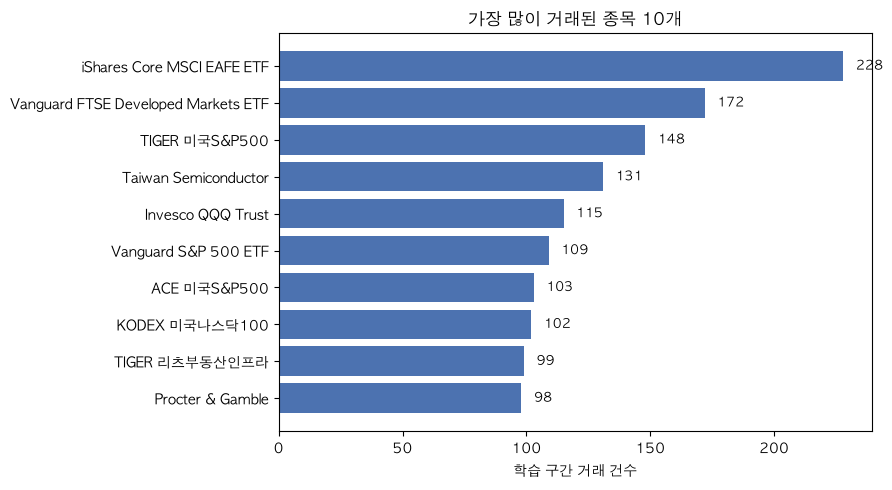

In [23]:
# 그래프를 그립니다. subplots 부터 show 까지는 한 셀에 붙어 있어야 그림이 한 번만 나옵니다.
fig, ax = plt.subplots(figsize=(9, 5))          # 그림판 만들기. figsize = 가로,세로 크기
ax.barh(이름_역순, 값_역순, color="#4C72B0")     # barh = 가로 막대그래프
ax.set_xlabel("학습 구간 거래 건수")              # 가로축 이름
ax.set_title("가장 많이 거래된 종목 10개")        # 그래프 제목

# 막대 끝에 숫자를 적어 줍니다. y 는 막대의 높이 자리(0번째, 1번째 ...)입니다.
y = 0
for v in 값_역순:
    ax.text(v + 5, y, str(v), va="center", fontsize=9)   # text(가로위치, 세로위치, 글자)
    y = y + 1

plt.tight_layout()                              # 글자가 잘리지 않게 여백 정리
plt.show()                                      # 화면에 그린다

상위 10개가 전체 거래에서 차지하는 비중을 보면, 특정 종목 몇 개에 거래가 몰려 있다는 것을 알 수 있습니다.

이런 쏠림이 있기 때문에 "인기 있는 것을 그냥 보여 주기"만 해도 어느 정도는 맞습니다.

오늘 재는 점수가 0이 아닌 이유가 여기에 있습니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.3 추천 목록을 만들고 점수를 낸다</mark>

추천 함수는 아주 단순합니다.

누가 오든 인기 순위표 위에서부터 10개를 잘라서 돌려줍니다.

한 가지만 신경 씁니다.

**이미 거래한 종목은 빼고** 줍니다.

이미 산 물건을 다시 추천하는 것은 추천이라고 할 수 없기 때문입니다.

그 처리는 `recsys.take()` 가 대신해 줍니다.

점수는 **Recall@10** 으로 잽니다.

채점 구간에서 그 사람이 실제로 거래한 종목 중 내가 준 10개 안에 몇 개가 들어 있었는지의 비율입니다.

예를 들어 그 사람이 실제로 4개를 거래했고 그중 1개를 맞혔다면 0.25입니다.

이것을 채점 대상 투자자 전원에 대해 평균 냅니다.

In [24]:
# 인기 순위표를 "종목 번호만 담은 리스트" 로 만듭니다.
인기순위_번호 = 종목별_거래건수.index   # index = 종목 번호 부분 (많은 순으로 정렬돼 있다)
인기순위 = list(인기순위_번호)          # list = 파이썬 리스트로 바꾸기

print(f"인기순위 {len(인기순위)}개 · 1위 {name_of[인기순위[0]]} · 꼴찌 {name_of[인기순위[-1]]}")


def 모두에게_같은_추천(user_id, seen):        # def = 함수 만들기. 재료 2개를 받는다
    """누가 오든 인기 순위표에서 아직 거래하지 않은 것 10개를 준다."""
    return recsys.take(인기순위, seen)      # take = 이미 본 것을 빼고 앞에서 10개


score, n_eval = recsys.recall_at_k(모두에게_같은_추천, train, test)   # 함수를 넘겨서 채점
print(f"Recall@10 = {score:.4f}   (채점 대상 투자자 {n_eval}명)")     # .4f = 소수 넷째 자리

인기순위 100개 · 1위 iShares Core MSCI EAFE ETF · 꼴찌 삼성에스디에스


Recall@10 = 0.2163   (채점 대상 투자자 266명)


In [25]:
recsys.record(1, "전체 인기", score,          # 주차 번호 · 이름 · 점수를 파일에 남긴다
              note="알고리즘 없음. 인기 상위 10개를 모두에게 동일하게 추천한 기준점")

레벨 1 · 전체 인기 · Recall@10 = 0.2163


{'level': 1,
 'name': '전체 인기',
 'recall_at_10': 0.2163,
 'note': '알고리즘 없음. 인기 상위 10개를 모두에게 동일하게 추천한 기준점'}

Recall@10 이 약 0.22 라는 것은, 그 사람이 실제로 거래한 종목 다섯 개 중 하나 정도를 우리가 미리 목록에 넣어 두었다는 뜻입니다.

알고리즘을 하나도 쓰지 않은 것 치고는 나쁘지 않은 숫자입니다.

그래서 이 숫자가 앞으로의 기준점이 됩니다.

### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.4 이것을 추천이라고 부를 수 있을까</mark>

성향이 정반대인 두 사람을 골라서 각자의 추천 목록을 나란히 놓아 봅니다.

한 사람은 원금을 지키는 것이 최우선인 안정형 투자자이고, 다른 한 사람은 손실을 감수하고 큰 수익을 노리는 공격형 투자자입니다.

(`users.csv` 의 성향 라벨은 **모델 입력으로 쓰지 않습니다.** 실제 서비스에는 이런 라벨이 없다고 가정하기 때문입니다.

여기서는 결과를 눈으로 확인하기 위한 용도로만 꺼내 씁니다.)

In [26]:
# 사람마다 "학습 구간에서 이미 거래했던 종목들"을 사전으로 만들어 둡니다.
# 추천할 때 이미 거래한 것을 빼려면 이 정보가 필요합니다.
사람별_묶음 = train.groupby("user_id")        # groupby = 같은 사람끼리 묶는다   → GroupBy
사람별_종목 = 사람별_묶음["item_id"]           # 각 묶음에서 종목 번호 열만        → SeriesGroupBy

# 리스트가 아니라 집합(set)으로 만듭니다. "이미 거래했나?" 를 확인할 때 집합이 훨씬 빠릅니다.
사람별_종목_집합 = 사람별_종목.apply(set)      # apply(set) = 묶음마다 중복을 없앤다  → Series
seen_map = 사람별_종목_집합.to_dict()          # {투자자: {종목번호, ...}} 사전       → dict

예시_투자자 = list(seen_map)[0]                # 사전에서 첫 번째 사람 하나
print(f"묶음 {사람별_묶음.ngroups}명 → 사전 {len(seen_map)}개")   # ngroups = 묶음 개수
print(f"예) {예시_투자자} 가 거래했던 종목 {len(seen_map[예시_투자자])}개")

묶음 285명 → 사전 285개
예) U0001 가 거래했던 종목 16개


In [27]:
# 채점 구간에 기록이 있는 사람만 비교할 수 있습니다.
채점대상 = set(test["user_id"])                 # 채점 구간에 나오는 사람들. 중복은 없앤다

안정형_행 = users[users["persona"] == "안정형"]   # 조건이 참인 행만 남긴다
안정형_아이디들 = 안정형_행["user_id"]             # 그중 아이디 열만

채점가능_안정형 = []
for u in 안정형_아이디들:
    if u in 채점대상:                            # 채점 구간에도 있는 사람만
        채점가능_안정형.append(u)

안정형 = 채점가능_안정형[0]                        # 그중 첫 번째 한 명
print(f"안정형 {안정형} (후보 {len(채점가능_안정형)}명 중 한 명)")

안정형 U0001 (후보 85명 중 한 명)


In [28]:
# 같은 방법으로 공격형도 한 명 고릅니다.
공격형_행 = users[users["persona"] == "공격형"]
공격형_아이디들 = 공격형_행["user_id"]

채점가능_공격형 = []
for u in 공격형_아이디들:
    if u in 채점대상:
        채점가능_공격형.append(u)

공격형 = 채점가능_공격형[0]
print(f"공격형 {공격형} (후보 {len(채점가능_공격형)}명 중 한 명)")

공격형 U0003 (후보 87명 중 한 명)


In [29]:
# 두 사람에게 각각 추천을 만들어서 나란히 놓고 봅니다.
목록_안정 = 모두에게_같은_추천(안정형, seen_map.get(안정형, set()))   # get = 없으면 빈 집합
목록_공격 = 모두에게_같은_추천(공격형, seen_map.get(공격형, set()))

# 종목 번호는 읽기 어려우니 이름으로 바꿔 둡니다.
안정_목록_이름 = []
for 번호 in 목록_안정:
    안정_목록_이름.append(name_of[번호])

공격_목록_이름 = []
for 번호 in 목록_공격:
    공격_목록_이름.append(name_of[번호])

비교 = pd.DataFrame({                           # 두 목록을 두 열로 나란히
    f"{안정형} (안정형)": 안정_목록_이름,
    f"{공격형} (공격형)": 공격_목록_이름,
})
비교.index = range(1, 11)                       # 행 번호를 1~10 으로
비교

,U0001 (안정형),U0003 (공격형)
1,Vanguard FTSE Developed Markets ETF,Vanguard FTSE Developed Markets ETF
2,TIGER 미국S&P500,Vanguard S&P 500 ETF
3,Taiwan Semiconductor,KODEX 미국나스닥100
4,Invesco QQQ Trust,TIGER 리츠부동산인프라
5,Vanguard S&P 500 ETF,Schwab US Dividend Equity ETF
6,ACE 미국S&P500,DB하이텍
7,KODEX 미국나스닥100,KODEX 국고채30년액티브
8,Schwab US Dividend Equity ETF,Salesforce
9,ProShares UltraPro QQQ,TIGER 은행고배당플러스TOP10
10,DB하이텍,KODEX 미국배당다우존스


In [30]:
# 두 목록에서 종목이 다른 자리만 모읍니다.
다른자리 = []
for i in range(10):                     # range(10) = 0부터 9까지
    if 목록_안정[i] != 목록_공격[i]:      # != 는 "다르다"
        다른자리.append(i)

print(f"열 자리 중 {len(다른자리)}자리가 다릅니다.")

열 자리 중 9자리가 다릅니다.


In [31]:
# 다른 자리를 하나씩 나란히 출력해 봅니다.
if len(다른자리) == 0:                   # == 는 "같다"
    print("두 사람의 추천 목록이 완전히 같습니다.")
else:
    print("그것도 이미 거래한 종목을 걸러낸 결과일 뿐,")
    print("추천 논리가 사람에 따라 달라진 것은 아닙니다.\n")
    for i in 다른자리:
        안정_종목 = name_of[목록_안정[i]]
        공격_종목 = name_of[목록_공격[i]]
        print(f"  {i + 1:2d}위  {안정_종목}  /  {공격_종목}")   # :2d = 두 칸 맞춰 정렬

그것도 이미 거래한 종목을 걸러낸 결과일 뿐,
추천 논리가 사람에 따라 달라진 것은 아닙니다.

   2위  TIGER 미국S&P500  /  Vanguard S&P 500 ETF
   3위  Taiwan Semiconductor  /  KODEX 미국나스닥100
   4위  Invesco QQQ Trust  /  TIGER 리츠부동산인프라
   5위  Vanguard S&P 500 ETF  /  Schwab US Dividend Equity ETF
   6위  ACE 미국S&P500  /  DB하이텍
   7위  KODEX 미국나스닥100  /  KODEX 국고채30년액티브
   8위  Schwab US Dividend Equity ETF  /  Salesforce
   9위  ProShares UltraPro QQQ  /  TIGER 은행고배당플러스TOP10
  10위  DB하이텍  /  KODEX 미국배당다우존스


### <mark style="display:block; background:#f8bbd0; color:#1a1a1a; padding:6px 12px; border-radius:4px">4.5 오늘의 마무리  `[PPT]`</mark>

원금 손실을 극도로 꺼리는 사람과 레버리지 상품까지 담는 사람에게 우리는 사실상 같은 목록을 내밀었습니다.

두 목록에 차이가 생기더라도 그것은 "이미 거래한 종목을 뺐다"는 이유뿐이고, 추천의 근거 자체는 두 사람에게 똑같았습니다.

이것을 추천이라고 부를 수 있을까요?

백화점 입구에 붙은 "이달의 베스트 10" 포스터와 다를 것이 없습니다.

포스터는 누가 지나가든 내용이 바뀌지 않습니다.

**2주차에는 사람마다 다른 목록을 만듭니다.** 그 사람이 지금까지 주로 담아 온 종목을 보고, 비슷한 성격의 종목을 골라 주는 규칙을 세울 것입니다.

그리고 오늘 쓴 Recall@10 이 정확히 무엇을 재는 숫자인지, Precision 이나 NDCG 같은 다른 지표와는 무엇이 다른지 직접 계산해 봅니다.